In [1]:
!git clone https://github.com/PauloHFS/gpt2-from-scratch.git

Cloning into 'gpt2-from-scratch'...
remote: Enumerating objects: 232, done.
remote: Counting objects: 100% (232/232), done.
remote: Compressing objects: 100% (172/172), done.
remote: Total 232 (delta 83), reused 180 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (232/232), 2.31 MiB | 14.00 MiB/s, done.
Resolving deltas: 100% (83/83), done.


In [2]:
%cd gpt2-from-scratch

/content/gpt2-from-scratch


# GPT From Scratch

Este repositório irá implementar o GPT 2 do zero, com o código bruto do modelo presente na pasta `src`.

O objetivo será realizar o seguinte fluxo de atividades:
* Leitura do dataset;
* Treina modelo;
* Plotagem de métricas durante treino;
* Processa modelo para gerar textos;
* Avaliação dos textos;
* Plotagem da avaliação;
* Conclusão.

---

# Preparando ambiente

Importando pacotes python para utilização do código

In [3]:
# Importando pacotes python

from os import mkdir, environ
from os.path import exists

from json import load

import torch
from torch.nn.functional import cross_entropy
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

np.random.seed(42)
torch.manual_seed(42)

Importando pacotes para execução do experimento

In [4]:
from src.dataload.tokenizer import Tokenizer
from src.gptmodel.model import GPTModel
from src.gptmodel.gqa_model import GQAModel

---

# Configurações para rodar o sistema

Aqui ocorrerá as constantes para o processamento do sistema:

In [5]:
RESULT_DIR = "results"

if not exists(RESULT_DIR): mkdir(RESULT_DIR)

Diretório de banco de dados:

In [6]:
DATASET_DIR = "dataset/"

Caminho final dos tokens:

In [7]:
TOKEN_TEXTS = f"{RESULT_DIR}/tokens.txt"

Caminho do melhor modelo:

In [8]:
BEST_MODEL_PATH = f"{RESULT_DIR}/best_model.pt"

Configuração do GPT:

In [9]:
GPT_CONFIGURATION = f"src/gpt_configurations.json"

Estatísticas:

In [10]:
TRAIN_RATIO = 0.8
BATCH_SIZE = 5

Configuração:

In [11]:
with open(GPT_CONFIGURATION, 'r') as f:
    CONFIGURATION = load(f)

In [12]:
CONFIGURATION_KEY = "GPT_CONFIG_SMALL_COLAB"
CONFIGURATION_KEY_GQA = "GQA_CONFIG"

In [13]:
configuration = CONFIGURATION[CONFIGURATION_KEY]
configuration_gqa = CONFIGURATION[CONFIGURATION_KEY_GQA]

In [14]:
configuration

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 256,
 'n_heads': 8,
 'n_layers': 8,
 'drop_rate': 0.1,
 'qkv_bias': False,
 'attention_type': 'gqa',
 'num_kv_groups': 4}

In [15]:
configuration_gqa

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 256,
 'n_heads': 12,
 'n_layers': 12,
 'hidden_dim': 768,
 'head_dim': 256,
 'qk_norm': True,
 'n_kv_groups': 4,
 'rope_base': 1000000.0,
 'dtype': 'torch.bfloat16'}

Ambientes de execução:

In [16]:
environ['CUDA_LAUNCH_BLOCKING'] = "1"

---

# Leitura do Dataset

Tokenizando todo o conjunto de dados para treinamento e salvando em um arquivo de texto:

In [17]:
tokenizer = Tokenizer(["utf-8", "latin1"])

In [18]:
tokenizer.generate_data(DATASET_DIR, TOKEN_TEXTS)

100%|██████████| 15/15 [00:00<00:00, 485.81it/s]


Carregando base de dados:

In [19]:
with open(TOKEN_TEXTS, 'r', encoding='utf-8') as f:
    contents = f.read()

In [20]:
train_dataloader, test_dataloader = tokenizer.create_dataloaders(
    contents,
    TRAIN_RATIO,
    BATCH_SIZE,
    configuration["context_length"],
    configuration["context_length"]
    )

---

# Treino dos modelos

Esta seção irá ocorrer a instanciação e geração dos modelos:

In [33]:
model = GPTModel(
    vocab_size=configuration["vocab_size"],
    emb_dim=configuration["emb_dim"],
    context_length=configuration["context_length"],
    drop_rate=configuration["drop_rate"],
    n_heads=8,
    n_layers=12,
    qkv_bias=configuration["qkv_bias"]
    )

In [22]:
model_gqa = GQAModel(
    configuration_gqa
)

In [23]:
print(torch.cuda.is_available())


True


In [34]:
base_trained, final_metrics_base = GPTModel._train(
    model=model,
    train_loader=train_dataloader,
    val_loader=test_dataloader,
    device_str="cuda",
    path=BEST_MODEL_PATH,
    epochs=3)

Training model on device: cuda


  0%|          | 0/3 [00:45<?, ?it/s]

Epoch 1/3 | Step 200 - Train Loss: 5.5554, Val Loss 5.3652, Throughput: 8150.2 tokens / sec


  0%|          | 0/3 [00:45<?, ?it/s]

New best model saved to results/best_model.pt with val_loss: 5.3652


...

 67%|██████▋   | 2/3 [12:44<04:21, 261.66s/it]

Epoch 3/3 | Step 3400 - Train Loss: 3.7423, Val Loss 3.9531, Throughput: 8597.8 tokens / sec


 67%|██████▋   | 2/3 [12:44<04:21, 261.66s/it]

New best model saved to results/best_model.pt with val_loss: 3.9531


100%|██████████| 3/3 [13:08<00:00, 262.86s/it]


In [27]:
gqa_trained, final_metrics_gqa = GQAModel._train(
    model=model_gqa,
    train_loader=train_dataloader,
    val_loader=test_dataloader,
    device_str="cuda",
    path=BEST_MODEL_PATH.replace(".pt","_gqa.pt"),
    epochs=3)

Training model on device: cuda


  0%|          | 0/3 [01:43<?, ?it/s]

Epoch 1/3 | Step 200 - Train Loss: 5.0422, Val Loss 4.8914, Throughput: 3657.7 tokens / sec
New best model saved to results/best_model_gqa.pt with val_loss: 4.8914


  0%|          | 0/3 [03:27<?, ?it/s]

Epoch 1/3 | Step 400 - Train Loss: 4.2930, Val Loss 4.3338, Throughput: 3502.0 tokens / sec


...

 67%|██████▋   | 2/3 [29:28<10:05, 605.93s/it]

Epoch 3/3 | Step 3400 - Train Loss: 2.9312, Val Loss 3.4585, Throughput: 3694.1 tokens / sec


 67%|██████▋   | 2/3 [29:29<10:05, 605.93s/it]

New best model saved to results/best_model_gqa.pt with val_loss: 3.4585


100%|██████████| 3/3 [30:23<00:00, 607.86s/it]


---

# Análise de treinamento

Nesta seção irá ocorrer a análise do treinamento do modelo GQA:

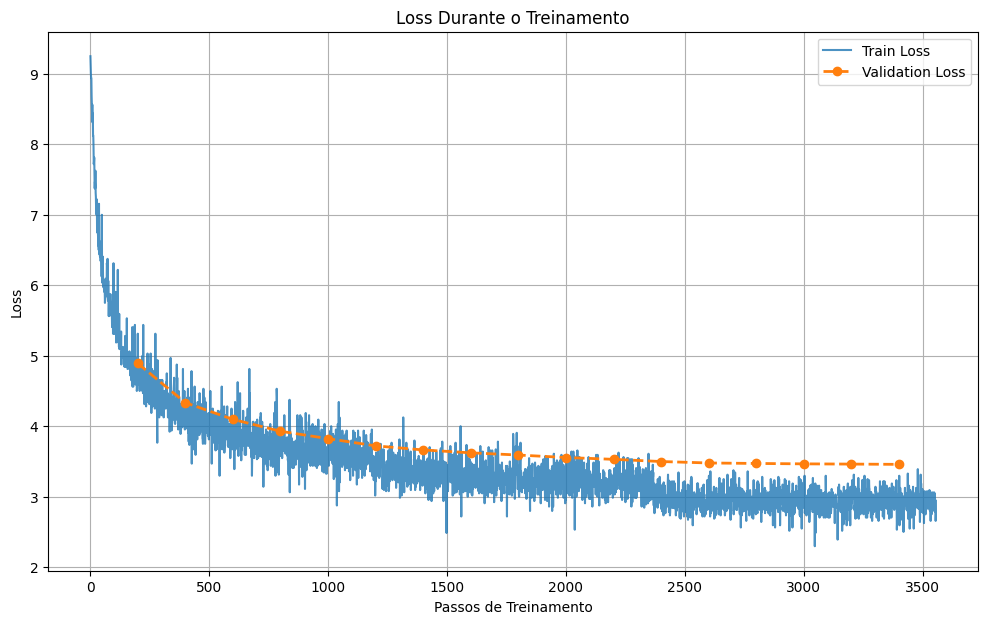

In [35]:
val_interval = 200

num_val_points = len(final_metrics_gqa.val_loss)
val_steps = np.arange(1, num_val_points + 1) * val_interval

fig = plt.figure(figsize=(12, 7))

plt.plot(
    np.arange(1, len(final_metrics_gqa.train_loss) + 1),
    final_metrics_gqa.train_loss,
    label='Train Loss',
    alpha=0.8
)

plt.plot(
    val_steps,
    final_metrics_gqa.val_loss,
    label='Validation Loss',
    marker='o',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Passos de Treinamento')
plt.ylabel('Loss')
plt.title('Loss Durante o Treinamento')
plt.legend()
plt.grid(True)
plt.show()

O gráfico exibe uma curva de aprendizado clássica e saudável. O treinamento iniciou com uma loss elevada (superior a 11.0), valor consistente com a performance de um modelo não treinado em um vocabulário extenso. Observa-se uma queda acentuada e rápida da loss nos passos iniciais (0-200), indicando que o modelo ajustou seus pesos eficientemente no começo do treinamento. A taxa de aprendizado diminui progressivamente, e a curva começa a se estabilizar em passos mais avançados, sugerindo que o modelo está convergindo.

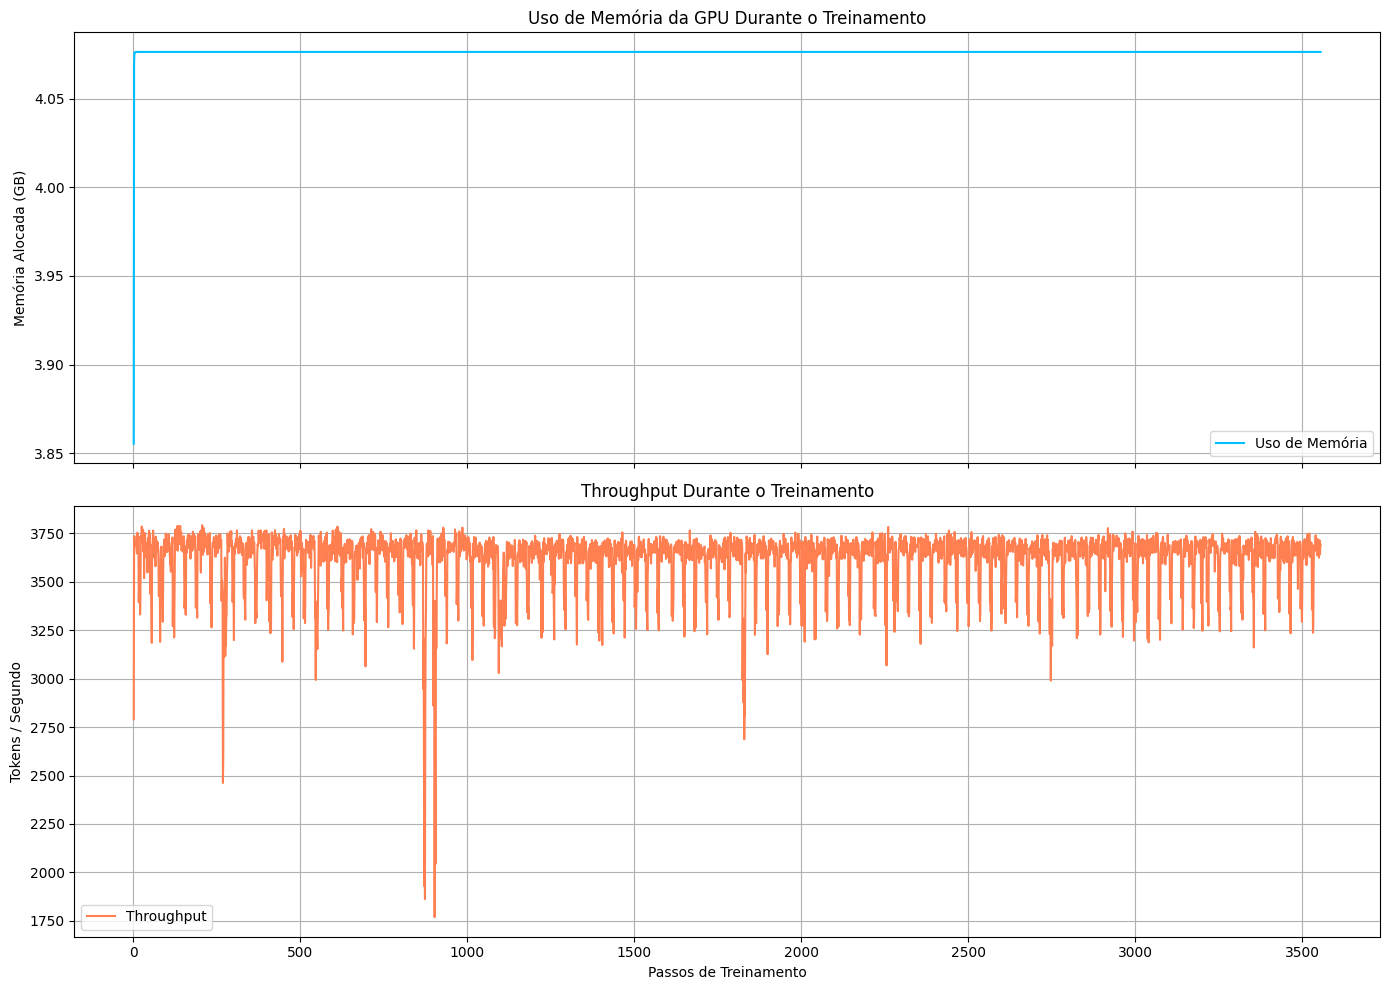

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(
    np.arange(1, len(final_metrics_gqa.gpu_memory) + 1),
    final_metrics_gqa.gpu_memory,
    color='deepskyblue',
    label='Uso de Memória'
)
axes[0].set_title('Uso de Memória da GPU Durante o Treinamento')
axes[0].set_ylabel('Memória Alocada (GB)')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(
    np.arange(1, len(final_metrics_gqa.throughput) + 1),
    final_metrics_gqa.throughput,
    color='coral',
    label='Throughput'
)
axes[1].set_title('Throughput Durante o Treinamento')
axes[1].set_ylabel('Tokens / Segundo')
axes[1].grid(True)
axes[1].legend()

plt.xlabel('Passos de Treinamento')

plt.tight_layout()

plt.show()

O uso de memória da GPU é constante, o que é bom, o sistema está estável. Já quanto ao throughput, o desempenho médio é alto, indicando processamento eficiente. No entanto, a alta variância e as quedas periódicas acentuadas revelam que o treinamento é limitado por gargalos de I/O (carregamento de dados, escrita de logs), não pela capacidade computacional da GPU.

---

Agora os mesmos gráficos com o GPT BASE

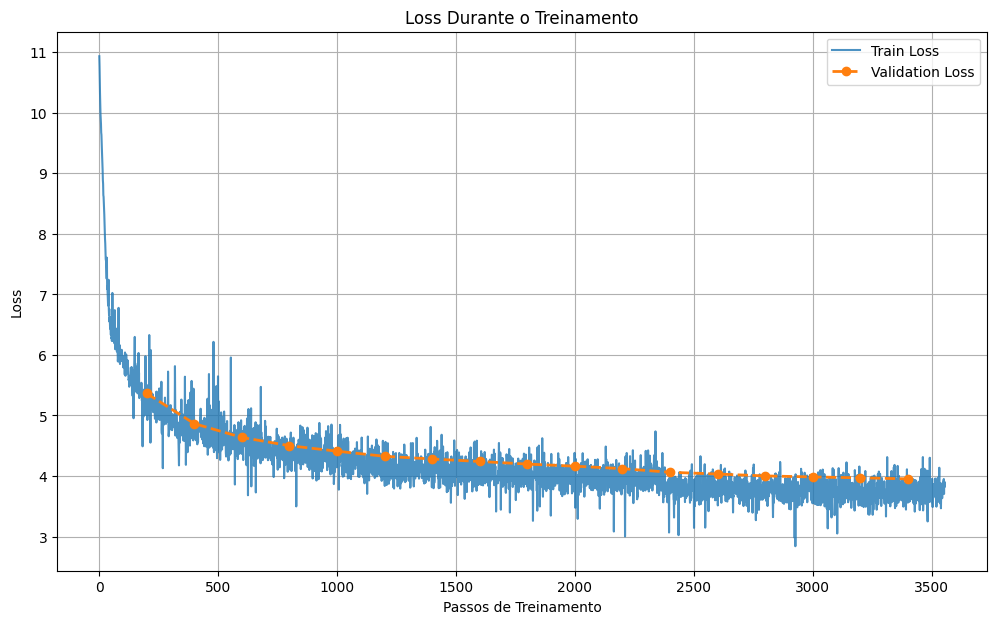

In [37]:
val_interval = 200

num_val_points = len(final_metrics_base.val_loss)
val_steps = np.arange(1, num_val_points + 1) * val_interval

fig = plt.figure(figsize=(12, 7))

plt.plot(
    np.arange(1, len(final_metrics_base.train_loss) + 1),
    final_metrics_base.train_loss,
    label='Train Loss',
    alpha=0.8
)

plt.plot(
    val_steps,
    final_metrics_base.val_loss,
    label='Validation Loss',
    marker='o',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Passos de Treinamento')
plt.ylabel('Loss')
plt.title('Loss Durante o Treinamento')
plt.legend()
plt.grid(True)
plt.show()

O gráfico exibe uma curva de aprendizado clássica e saudável. O treinamento iniciou com uma loss elevada (superior a 11.0), valor consistente com a performance de um modelo não treinado em um vocabulário extenso. Observa-se uma queda acentuada e rápida da loss nos passos iniciais (0-200), indicando que o modelo ajustou seus pesos eficientemente no começo do treinamento. A taxa de aprendizado diminui progressivamente, e a curva começa a se estabilizar em passos mais avançados, sugerindo que o modelo está convergindo.

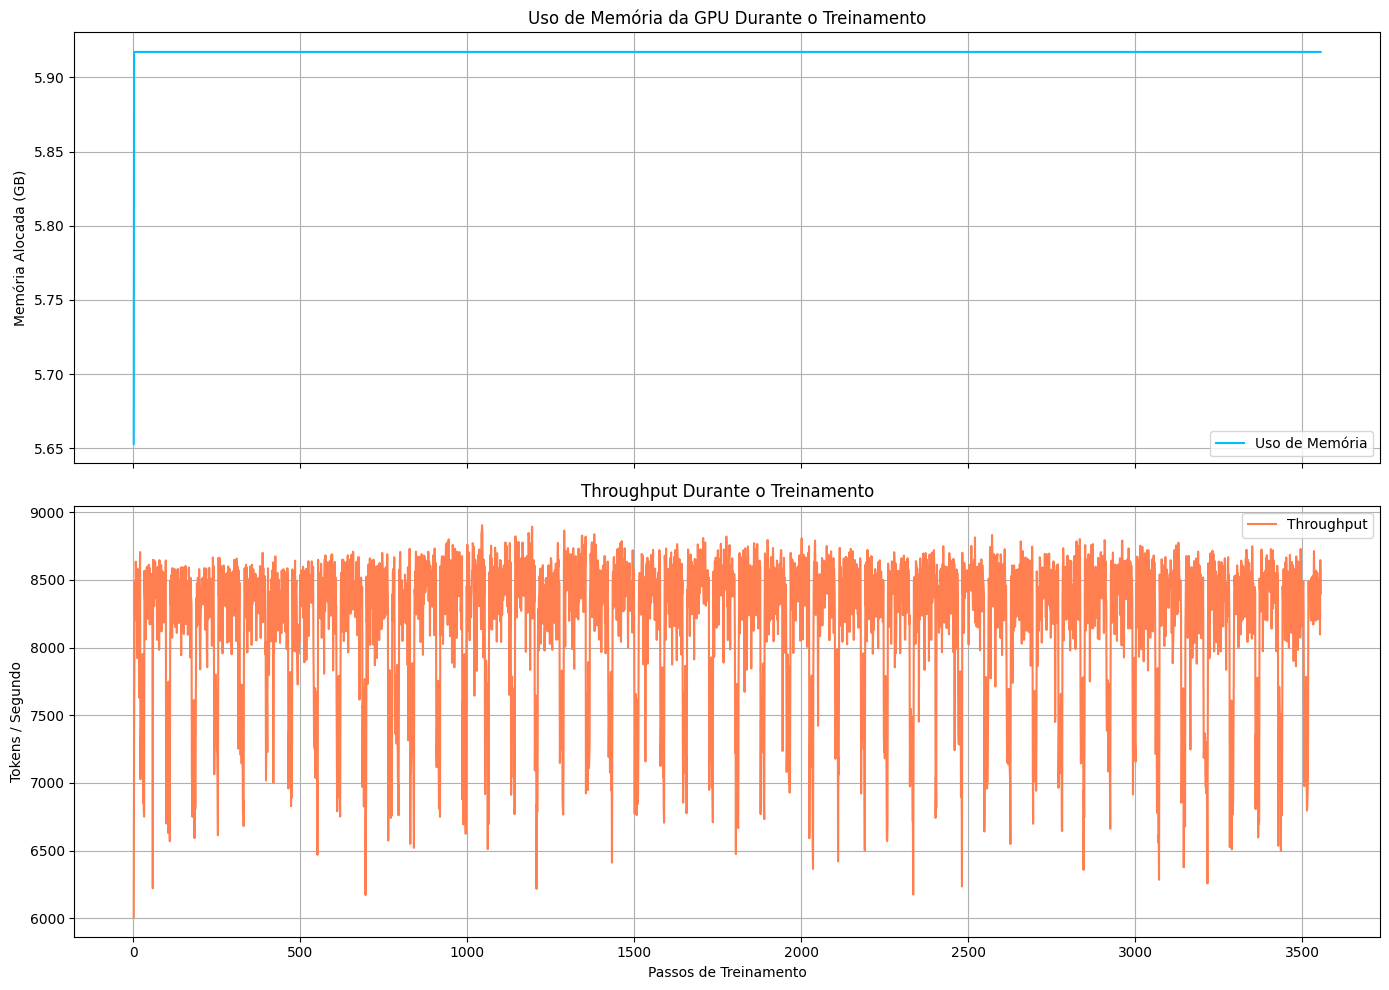

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(
    np.arange(1, len(final_metrics_base.gpu_memory) + 1),
    final_metrics_base.gpu_memory,
    color='deepskyblue',
    label='Uso de Memória'
)
axes[0].set_title('Uso de Memória da GPU Durante o Treinamento')
axes[0].set_ylabel('Memória Alocada (GB)')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(
    np.arange(1, len(final_metrics_base.throughput) + 1),
    final_metrics_base.throughput,
    color='coral',
    label='Throughput'
)
axes[1].set_title('Throughput Durante o Treinamento')
axes[1].set_ylabel('Tokens / Segundo')
axes[1].grid(True)
axes[1].legend()

plt.xlabel('Passos de Treinamento')

plt.tight_layout()

plt.show()

O uso de memória da GPU é constante, o que é bom, o sistema está estável. Já quanto ao throughput, o desempenho médio é alto, indicando processamento eficiente. No entanto, a alta variância e as quedas periódicas acentuadas revelam que o treinamento é limitado por gargalos de I/O (carregamento de dados, escrita de logs), não pela capacidade computacional da GPU.

---

# Geração de Textos para avaliação

Esta seção irá ocorrer a geração de textos para avaliação:

In [47]:
# BEST_MODEL_PATH = "results/best_model.pt"
# device = "cuda" if torch.cuda.is_available() else "cpu"

# model = GPTModel(
#     vocab_size=configuration["vocab_size"],
#     emb_dim=configuration["emb_dim"],
#     context_length=configuration["context_length"],
#     drop_rate=configuration["drop_rate"],
#     n_heads=configuration["n_heads"],
#     n_layers=configuration["n_layers"],
#     qkv_bias=configuration["qkv_bias"],
# )

# model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
# model.to(device)
base_trained.eval()

tokenizer = AutoTokenizer.from_pretrained("gpt2")
eos_token_id = tokenizer.eos_token_id

prompt_text = "Inteligência Artificial é um campo da ciência da computação"
encoded_prompt = tokenizer.encode(prompt_text, return_tensors="pt").to(device)

print(f"Prompt: '{prompt_text}'\n")

with torch.no_grad():
    output_tokens_base = base_trained.generate(
        idx=encoded_prompt,
        max_new_tokens=100,
        context_size=configuration["context_length"],
        temperature=0.7,
        top_k=50,
        eos_id=eos_token_id
    )
    output_tokens_gqa = gqa_trained.generate(
        idx=encoded_prompt,
        max_new_tokens=100,
        context_size=configuration["context_length"],
        temperature=0.7,
        top_k=50,
        eos_id=eos_token_id
    )

decoded_text_base = tokenizer.decode(output_tokens_base[0])
decoded_text_gqa = tokenizer.decode(output_tokens_gqa[0])

print("-"*50)
print("GPT Normal:",decoded_text_base)
print("-"*50)
print("GQA:",decoded_text_gqa)

Prompt: 'Inteligência Artificial é um campo da ciência da computação'

--------------------------------------------------
GPT Normal: Inteligência Artificial é um campo da ciência da computação
esperança e depois de mãos.
Alegrei-lo em que ou, com ao dizendo, e ao pai, que parecia o
me um pobrebro; como do mundo.

Rubi-se espero o rapaz de trabalho, e das vinha de também das pela cabelo, quando
com isso que
--------------------------------------------------
GQA: Inteligência Artificial é um campo da ciência da computação. Ainda assim,
mas o fim de a ser natural que ela não era a mesma casa, e era
a verdadeira. Esta, ao menos, a gente e a lua, lhe fez um lado de
minutos, ao cabo da vida, que a leitora é do que a ausência
das mãos de todo o pai,


O texto gerado é incoerente porque o modelo está subtreinado devido aos poucos dados, 8 livros é um material insuficiente para o modelo aprender a complexidade da língua portuguesa. Além disso o pouco treinamento, apenas uma época de treinamento não foi o bastante para o modelo aprender nem mesmo com os poucos dados disponíveis.

---

# Avaliação dos textos

Esta seção irá ocorrer a avaliação dos textos gerados pela LLM, tanto numericamente como graficamente.

In [45]:
def calculate_perplexity(model, dataloader, device):
    model.eval()
    total_loss = 0
    num_batches = 0

    with torch.no_grad():
        for input_ids, target_ids in dataloader:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)

            logits = model(input_ids)

            loss = cross_entropy(
                logits.view(-1, logits.size(-1)),
                target_ids.view(-1)
            )

            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / num_batches
    perplexity = np.exp(avg_loss)
    return perplexity

ppl_base = calculate_perplexity(base_trained, test_dataloader, device)
ppl_gqa = calculate_perplexity(gqa_trained, test_dataloader, device)

print(f"Perplexidade no conjunto de teste (GPT normal): {ppl_base:.2f}")
print(f"Perplexidade no conjunto de teste (GPT GQA): {ppl_gqa:.2f}")


Perplexidade no conjunto de teste (GPT normal): 51.94
Perplexidade no conjunto de teste (GPT GQA): 31.74


Surpreendentemente, este valor é bom para um treinamento tão inicial. Mostra que o modelo já está aprendendo padrões e não está "chutando" aleatoriamente. A métrica confirma que o treinamento está funcionando e na direção correta, apesar de a geração de texto ainda ser incoerente.

---

# Conclusão

Por fim, aqui teremos uma seção de feedback a respeito das atividades desenvolvidas!